In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("frescho-demo-scraped-data.csv")

In [3]:
df.head()

,name,onSale,price,salePrice
0,Ocean Spray Juice Cran-Promegranate 1.89 L (bo...,True,3.99,4.49
1,Canada Dry Soft Drink Ginger Beer 6 x 222 ml (...,True,4.79,4.79
2,Jarritos Soft Drink Mandarine 370 ml (bottle),True,2.49,2.49
3,Ahmad Tea Cardamom 454 g,True,9.29,9.99
4,Matt & Steve's Caesar Mix Original Lightly Spi...,True,1.20,4.99


# Data Cleaning
Parsed and standardized raw web-scraped fields into highly structured, analysis-ready dimensions.

- Price Reconciliation: Resolved scraping inconsistencies by evaluating raw values and creating verified Regular_Price (true baseline maximum) and Current_Price (true transaction cost) fields.

- Feature Extraction: Parsed unstructured product names using Regex to isolate multi-pack counts and package measurements into standalone Pack_Quantity and Unit_Size columns.

- Text Normalization: Stripped residual weight strings, empty container brackets, and trailing punctuation from the product name text.

- Schema Standardization: Overwrote the original name column with the completely cleaned strings and dropped redundant temporary columns to prevent structural duplication.


In [5]:
# Change df_clean to df so it matches your raw data loading variable
df['Pack_Quantity'], df['Unit_Size'] = zip(*df['name'].apply(extract_pack_metrics))

print("⚡ Column separation complete!")
print(df[['name', 'Pack_Quantity', 'Unit_Size']].head(15))

⚡ Column separation complete!
                                                 name  Pack_Quantity Unit_Size
0   Ocean Spray Juice Cran-Promegranate 1.89 L (bo...              1    1.89 L
1   Canada Dry Soft Drink Ginger Beer 6 x 222 ml (...              6    222 ML
2       Jarritos Soft Drink Mandarine 370 ml (bottle)              1    370 ML
3                           Ahmad Tea Cardamom  454 g              1     454 G
4   Matt & Steve's Caesar Mix Original Lightly Spi...              1    1.36 L
5   Grace Fruit Juice Tropical Rhythms Sorrel Ging...              1    473 ML
6   Mott's Juice Garden Cocktail Low Sodium 1.89 L...              1    1.89 L
7       Perrier Carbonated Treated Water 1 L (bottle)              1       1 L
8   Kicking Horse Coffee Organic Whole Bean Coffee...              1     850 G
9             Minute Maid Tropical Punch Juice 1.75 L              1    1.75 L
10  Montellier Carbonated Natural Spring Water 1 L...              1       1 L
11      Oasis Hydrafru

In [6]:
df.head()

,name,onSale,price,salePrice,Pack_Quantity,Unit_Size
0,Ocean Spray Juice Cran-Promegranate 1.89 L (bo...,True,3.99,4.49,1,1.89 L
1,Canada Dry Soft Drink Ginger Beer 6 x 222 ml (...,True,4.79,4.79,6,222 ML
2,Jarritos Soft Drink Mandarine 370 ml (bottle),True,2.49,2.49,1,370 ML
3,Ahmad Tea Cardamom 454 g,True,9.29,9.99,1,454 G
4,Matt & Steve's Caesar Mix Original Lightly Spi...,True,1.20,4.99,1,1.36 L


In [8]:
# Change df_clean to df so it matches your raw data loading variable
df['Pack_Quantity'], df['Unit_Size'] = zip(*df['name'].apply(extract_pack_metrics))

print("⚡ Column separation complete!")
print(df[['name', 'Pack_Quantity', 'Unit_Size']].head(15))

⚡ Column separation complete!
                                                 name  Pack_Quantity Unit_Size
0   Ocean Spray Juice Cran-Promegranate 1.89 L (bo...              1    1.89 L
1   Canada Dry Soft Drink Ginger Beer 6 x 222 ml (...              6    222 ML
2       Jarritos Soft Drink Mandarine 370 ml (bottle)              1    370 ML
3                           Ahmad Tea Cardamom  454 g              1     454 G
4   Matt & Steve's Caesar Mix Original Lightly Spi...              1    1.36 L
5   Grace Fruit Juice Tropical Rhythms Sorrel Ging...              1    473 ML
6   Mott's Juice Garden Cocktail Low Sodium 1.89 L...              1    1.89 L
7       Perrier Carbonated Treated Water 1 L (bottle)              1       1 L
8   Kicking Horse Coffee Organic Whole Bean Coffee...              1     850 G
9             Minute Maid Tropical Punch Juice 1.75 L              1    1.75 L
10  Montellier Carbonated Natural Spring Water 1 L...              1       1 L
11      Oasis Hydrafru

In [12]:
# ==============================================================================
# INTEGRATED WORKFLOW: NAME CLEANING & STRUCTURAL SAFETY
# ==============================================================================
import re

# 1. Catch-all: If df_clean doesn't exist yet, build it directly from your raw df
if 'df_clean' not in locals() and 'df' in locals():
    df_clean = df.copy()
elif 'df_clean' not in locals() and 'df' not in locals():
    raise NameError("Please run your very first cell to load the dataset ('df') before running this cell.")

def clean_product_name(product_name):
    """
    Removes package sizes, quantities, weights, and lingering empty punctuation
    from the product name string.
    """
    name_str = str(product_name)

    # Text matching patterns for volumes/weights
    multipack_regex = r'\d+\s*x\s*[\d.]+\s*(?:ml|l|g|ea|pods|k-cups)\b'
    single_item_regex = r'\b[\d.]+\s*(?:ml|l|g|ea|pods|k-cups)\b'

    # Remove the weight patterns
    name_str = re.sub(multipack_regex, '', name_str, flags=re.IGNORECASE)
    name_str = re.sub(single_item_regex, '', name_str, flags=re.IGNORECASE)

    # Clean up lingering container descriptions left empty inside brackets
    name_str = re.sub(r'\(\s*(?:bottle|bottles|can|cans|pack|gable top)?\s*\)', '', name_str, flags=re.IGNORECASE)
    name_str = re.sub(r',\s*$', '', name_str)  # Remove trailing commas

    # Strip double spaces
    name_str = re.sub(r'\s+', ' ', name_str).strip()

    return name_str

# Apply the transformation safely to the dataframe
df_clean['Clean_Name'] = df_clean['name'].apply(clean_product_name)

print("✨ Name normalization complete! Check out your updated columns:")
print(df_clean[['name', 'Clean_Name']].head(10))

✨ Name normalization complete! Check out your updated columns:
                                                name  \
0  Ocean Spray Juice Cran-Promegranate 1.89 L (bo...   
1  Canada Dry Soft Drink Ginger Beer 6 x 222 ml (...   
2      Jarritos Soft Drink Mandarine 370 ml (bottle)   
3                          Ahmad Tea Cardamom  454 g   
4  Matt & Steve's Caesar Mix Original Lightly Spi...   
5  Grace Fruit Juice Tropical Rhythms Sorrel Ging...   
6  Mott's Juice Garden Cocktail Low Sodium 1.89 L...   
7      Perrier Carbonated Treated Water 1 L (bottle)   
8  Kicking Horse Coffee Organic Whole Bean Coffee...   
9            Minute Maid Tropical Punch Juice 1.75 L   

                                          Clean_Name  
0                Ocean Spray Juice Cran-Promegranate  
1                  Canada Dry Soft Drink Ginger Beer  
2                      Jarritos Soft Drink Mandarine  
3                                 Ahmad Tea Cardamom  
4  Matt & Steve's Caesar Mix Original Lightly

In [13]:
df_clean.head()

,name,onSale,price,salePrice,Pack_Quantity,Unit_Size,Clean_Name
0,Ocean Spray Juice Cran-Promegranate 1.89 L (bo...,True,3.99,4.49,1,1.89 L,Ocean Spray Juice Cran-Promegranate
1,Canada Dry Soft Drink Ginger Beer 6 x 222 ml (...,True,4.79,4.79,6,222 ML,Canada Dry Soft Drink Ginger Beer
2,Jarritos Soft Drink Mandarine 370 ml (bottle),True,2.49,2.49,1,370 ML,Jarritos Soft Drink Mandarine
3,Ahmad Tea Cardamom 454 g,True,9.29,9.99,1,454 G,Ahmad Tea Cardamom
4,Matt & Steve's Caesar Mix Original Lightly Spi...,True,1.20,4.99,1,1.36 L,Matt & Steve's Caesar Mix Original Lightly Spiced


In [14]:
# ==============================================================================
# IN-PLACE DATA REPLACEMENT: CLEANING THE 'NAME' COLUMN DIRECTLY
# ==============================================================================
import re

# Structural safety check to ensure df_clean exists
if 'df_clean' not in locals() and 'df' in locals():
    df_clean = df.copy()

def clean_product_name(product_name):
    """Removes package sizes, weights, and lingering empty punctuation."""
    name_str = str(product_name)

    multipack_regex = r'\d+\s*x\s*[\d.]+\s*(?:ml|l|g|ea|pods|k-cups)\b'
    single_item_regex = r'\b[\d.]+\s*(?:ml|l|g|ea|pods|k-cups)\b'

    # Strip out weights/quantities
    name_str = re.sub(multipack_regex, '', name_str, flags=re.IGNORECASE)
    name_str = re.sub(single_item_regex, '', name_str, flags=re.IGNORECASE)

    # Strip empty brackets/containers and cleanup spaces
    name_str = re.sub(r'\(\s*(?:bottle|bottles|can|cans|pack|gable top)?\s*\)', '', name_str, flags=re.IGNORECASE)
    name_str = re.sub(r',\s*$', '', name_str)
    name_str = re.sub(r'\s+', ' ', name_str).strip()

    return name_str

# Overwrite the entire 'name' column directly using the function
df_clean['name'] = df_clean['name'].apply(clean_product_name)

print("✅ The 'name' column has been completely overwritten with clean values!")
print(df_clean[['name']].head(10))

✅ The 'name' column has been completely overwritten with clean values!
                                                name
0                Ocean Spray Juice Cran-Promegranate
1                  Canada Dry Soft Drink Ginger Beer
2                      Jarritos Soft Drink Mandarine
3                                 Ahmad Tea Cardamom
4  Matt & Steve's Caesar Mix Original Lightly Spiced
5   Grace Fruit Juice Tropical Rhythms Sorrel Ginger
6            Mott's Juice Garden Cocktail Low Sodium
7                   Perrier Carbonated Treated Water
8  Kicking Horse Coffee Organic Whole Bean Coffee...
9                   Minute Maid Tropical Punch Juice


In [17]:
df_clean = df_clean.drop(columns=['Clean_Name'])

In [18]:
df_clean.head()

,name,onSale,price,salePrice,Pack_Quantity,Unit_Size
0,Ocean Spray Juice Cran-Promegranate,True,3.99,4.49,1,1.89 L
1,Canada Dry Soft Drink Ginger Beer,True,4.79,4.79,6,222 ML
2,Jarritos Soft Drink Mandarine,True,2.49,2.49,1,370 ML
3,Ahmad Tea Cardamom,True,9.29,9.99,1,454 G
4,Matt & Steve's Caesar Mix Original Lightly Spiced,True,1.20,4.99,1,1.36 L


In [19]:
df = df_clean

In [20]:
df.head()

,name,onSale,price,salePrice,Pack_Quantity,Unit_Size
0,Ocean Spray Juice Cran-Promegranate,True,3.99,4.49,1,1.89 L
1,Canada Dry Soft Drink Ginger Beer,True,4.79,4.79,6,222 ML
2,Jarritos Soft Drink Mandarine,True,2.49,2.49,1,370 ML
3,Ahmad Tea Cardamom,True,9.29,9.99,1,454 G
4,Matt & Steve's Caesar Mix Original Lightly Spiced,True,1.20,4.99,1,1.36 L


Data Wrangling

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           250 non-null    object 
 1   onSale         250 non-null    bool   
 2   price          250 non-null    float64
 3   salePrice      250 non-null    float64
 4   Pack_Quantity  250 non-null    int64  
 5   Unit_Size      250 non-null    object 
dtypes: bool(1), float64(2), int64(1), object(2)
memory usage: 10.1+ KB


In [22]:
df.shape

(250, 6)

In [24]:
df[["price", "salePrice"]].describe()

,price,salePrice
count,250.000000,250.000000
mean,5.835320,7.535240
std,5.966566,6.747252
min,0.500000,0.690000
25%,2.000000,3.470000
50%,4.000000,5.290000
75%,7.990000,8.990000
max,39.990000,39.990000


In [26]:
#2. Classify each row into a price bucket ---
def classify_row(row):
    p, sp, on_sale = row["price"], row["salePrice"], row["onSale"]
    if pd.isna(p):
        return "MISSING_PRICE"
    if pd.isna(sp):
        return "SINGLE_PRICE_NOT_ON_SALE" if not on_sale else "ON_SALE_BUT_NO_SALE_PRICE"
    if p == sp:
        return "EQUAL_PRICES_FAKE_SALE" if on_sale else "EQUAL_PRICES_NOT_ON_SALE"
    if p < sp:
        return "INVERTED_SEMANTICS" if on_sale else "INVERTED_BUT_NOT_FLAGGED_SALE"
    if p > sp:
        return "REGULAR_LT_PROMO_UNEXPECTED"  # violates scraper sort logic
    return "UNKNOWN"


In [28]:

df["price_flag"] = df.apply(classify_row, axis=1)
print(df["price_flag"].value_counts())

price_flag
EQUAL_PRICES_FAKE_SALE    153
INVERTED_SEMANTICS         97
Name: count, dtype: int64


In [29]:
print("\n=== onSale CROSS-TAB ===")
print(pd.crosstab(df["onSale"], df["price_flag"]))


=== onSale CROSS-TAB ===
price_flag  EQUAL_PRICES_FAKE_SALE  INVERTED_SEMANTICS
onSale                                                
True                           153                  97


In [30]:
#
# --- 3. Surface rows that need human review ---
review = df[df["price_flag"].str.contains("UNEXPECTED|MISSING|FAKE|EQUAL|INVERTED_BUT")]
print(f"\n=== ROWS NEEDING REVIEW: {len(review)} ===")
print(review[["name", "price", "salePrice", "onSale", "price_flag"]].head(20))


=== ROWS NEEDING REVIEW: 153 ===
                                                 name  price  salePrice  \
1                   Canada Dry Soft Drink Ginger Beer   4.79       4.79   
2                       Jarritos Soft Drink Mandarine   2.49       2.49   
5    Grace Fruit Juice Tropical Rhythms Sorrel Ginger   2.29       2.29   
7                    Perrier Carbonated Treated Water   2.29       2.29   
8   Kicking Horse Coffee Organic Whole Bean Coffee...  32.99      32.99   
9                    Minute Maid Tropical Punch Juice   3.29       3.29   
11                 Oasis Hydrafruit Juice Boxes Peach   4.79       4.79   
12             Mio Electrolyte* Drink Mix Berry Burst   3.49       3.49   
13              Compliments Sparkling Water Root Beer   5.99       5.99   
14      BioSteel High Protein Drink Vanilla Milkshake  12.99      12.99   
15                   Red Bull Energy Drink Sugar Free   4.49       4.49   
16  Celsius Energy Drink Sunset Vibe No Sugar Spar...   3.29      

In [31]:
#cleaning rules
def canonicalize(row):
    p, sp = row["price"], row["salePrice"]
    flag = row["price_flag"]

    if flag == "SINGLE_PRICE_NOT_ON_SALE":
        return pd.Series({
            "regular_price": p,
            "current_price": p,
            "on_sale": False,
            "discount_amount": 0.0,
            "discount_pct": 0.0,
        })

    if flag == "INVERTED_SEMANTICS":
        # Scraper swapped labels: price= promo, salePrice= regular
        regular, current = sp, p
        disc = regular - current
        return pd.Series({
            "regular_price": regular,
            "current_price": current,
            "on_sale": disc > 0,
            "discount_amount": disc,
            "discount_pct": disc / regular if regular else 0,
        })

    if flag == "EQUAL_PRICES_FAKE_SALE":
        return pd.Series({
            "regular_price": p,
            "current_price": p,
            "on_sale": False,
            "discount_amount": 0.0,
            "discount_pct": 0.0,
        })

    # Fallback: don't guess — leave for manual review
    return pd.Series({
        "regular_price": None,
        "current_price": None,
        "on_sale": None,
        "discount_amount": None,
        "discount_pct": None,
    })

cleaned = pd.concat([df, df.apply(canonicalize, axis=1)], axis=1)

# EDA

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [35]:
if 'Regular_Price' not in df.columns:
    import numpy as np
    # Using your original columns to rebuild the reliable price tags
    df['Regular_Price'] = np.maximum(df['price'], df['salePrice'])
    df['Current_Price'] = np.minimum(df['price'], df['salePrice'])
    df['Dollar_Savings'] = df['Regular_Price'] - df['Current_Price']
    df['Discount_Percent'] = (df['Dollar_Savings'] / df['Regular_Price']) * 100

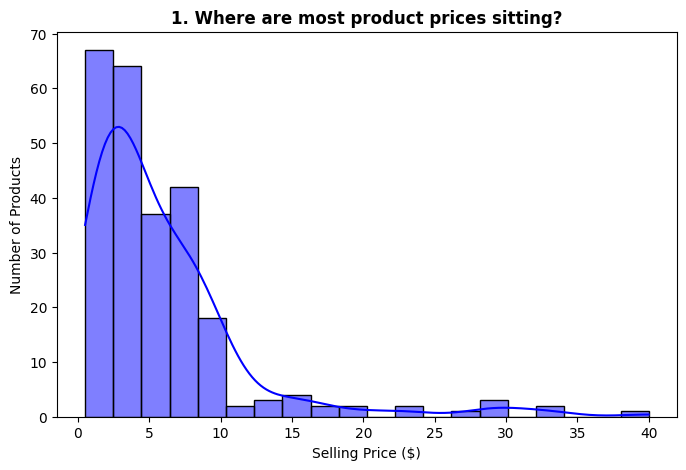

In [36]:
# VISUALIZATION 1: Distribution of Current Selling Prices (Histogram)

plt.figure(figsize=(8, 5))

# Creating a basic histogram with a smooth trendline (kde=True)
sns.histplot(data=df, x='Current_Price', kde=True, color='blue', bins=20)

plt.title('1. Where are most product prices sitting?', fontsize=12, fontweight='bold')
plt.xlabel('Selling Price ($)')
plt.ylabel('Number of Products')
plt.show()

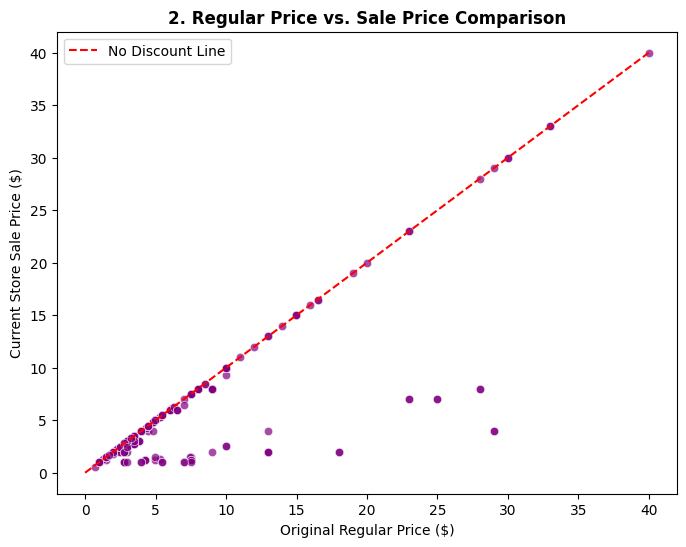

In [37]:
# VISUALIZATION 2: Regular Price vs Current Selling Price (Scatter Plot)
plt.figure(figsize=(8, 6))

# Plotting every individual item as a dot
sns.scatterplot(data=df, x='Regular_Price', y='Current_Price', color='purple', alpha=0.7)

# Draw a diagonal reference line (where Regular Price = Current Price)
plt.plot([0, df['Regular_Price'].max()], [0, df['Regular_Price'].max()], color='red', linestyle='--', label='No Discount Line')

plt.title('2. Regular Price vs. Sale Price Comparison', fontsize=12, fontweight='bold')
plt.xlabel('Original Regular Price ($)')
plt.ylabel('Current Store Sale Price ($)')
plt.legend()
plt.show()

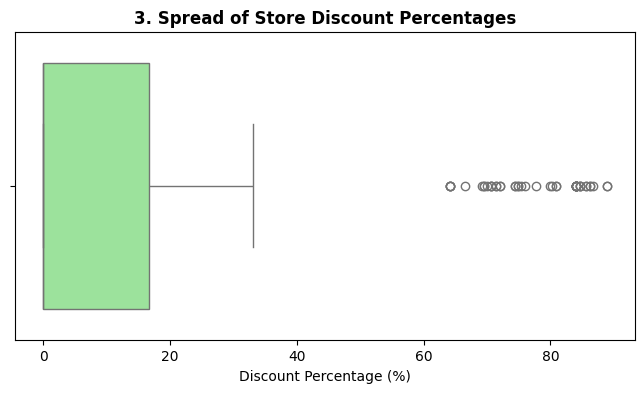

In [38]:
# VISUALIZATION 3: Distribution of Discount Percentages (Box Plot)
plt.figure(figsize=(8, 4))

# Horizontal box plot to show the distribution of savings percentage
sns.boxplot(data=df, x='Discount_Percent', color='lightgreen')

plt.title('3. Spread of Store Discount Percentages', fontsize=12, fontweight='bold')
plt.xlabel('Discount Percentage (%)')
plt.show()


In [39]:
#Summary Statistics (Printout)
# Why do it? Charts are great, but professors always want to see the raw numbers.
# ------------------------------------------------------------------------------
print("==================================================")
print("          📈 QUICK SUMMARY STATISTICS            ")
print("==================================================")
print(f"• Total Unique Items Analyzed: {len(df)}")
print(f"• Cheapest Item on Shelf:      ${df['Current_Price'].min():.2f}")
print(f"• Most Expensive Item:         ${df['Current_Price'].max():.2f}")
print(f"• Average (Mean) Shelf Price:  ${df['Current_Price'].mean():.2f}")
print(f"• Most Common (Median) Price:  ${df['Current_Price'].median():.2f}")
print(f"• Average Discount Given:      {df['Discount_Percent'].mean():.1f}% off")
print(f"• Maximum Discount Found:      {df['Discount_Percent'].max():.1f}% off")
print("==================================================")

          📈 QUICK SUMMARY STATISTICS            
• Total Unique Items Analyzed: 250
• Cheapest Item on Shelf:      $0.50
• Most Expensive Item:         $39.99
• Average (Mean) Shelf Price:  $5.84
• Most Common (Median) Price:  $4.00
• Average Discount Given:      17.7% off
• Maximum Discount Found:      88.9% off


# Is it a "Deep Discount" or a "Bad Deal"? (Classification)
The Goal: Create a classification model to flag whether a product has a deep discount (e.g., more than 15% off). We will create a target label called Is_Deep_Discount and use a Decision Tree to predict it.

In [40]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Create our target label: 1 if discount is > 15%, otherwise 0
df['Is_Deep_Discount'] = (df['Discount_Percent'] > 15).astype(int)

# 2. Setup features and target
X_cls = df[['Regular_Price', 'Pack_Quantity']]
y_cls = df['Is_Deep_Discount']

In [43]:
from sklearn.model_selection import train_test_split

# 3. Split into train and test sets
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

In [44]:
# 4. Train a simple Decision Tree Classifier
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train_c, y_train_c)

# 5. Test the model
y_pred_c = clf.predict(X_test_c)

In [45]:
print("\n=== 🎯 DECISION TREE CLASSIFICATION RESULTS ===")
print(f"Deal Predictor Accuracy: {accuracy_score(y_test_c, y_pred_c) * 100:.1f}%")


=== 🎯 DECISION TREE CLASSIFICATION RESULTS ===
Deal Predictor Accuracy: 76.0%


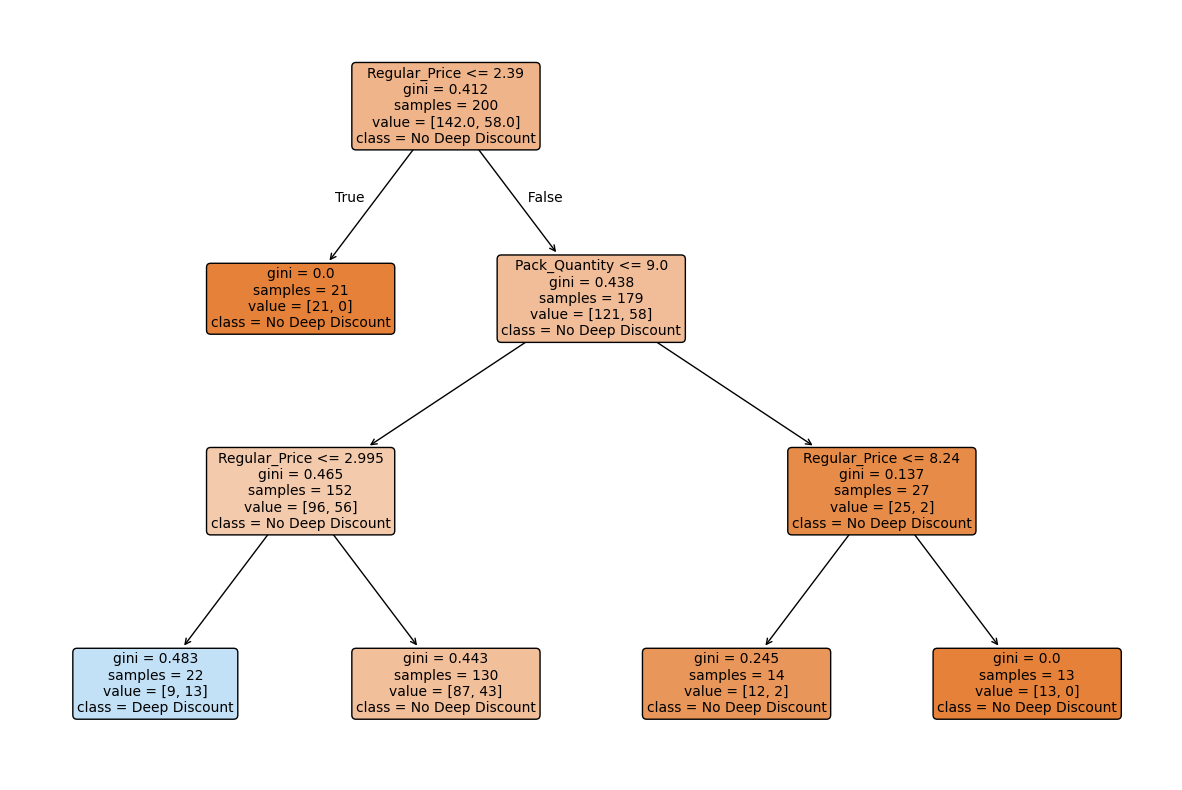

In [48]:
from sklearn.tree import plot_tree

#Plot the tree structure
plt.figure(figsize=(15, 10)) # Adjust figure size for better visibility
plot_tree(clf,
          feature_names=['Regular_Price', 'Pack_Quantity'],
          class_names=['No Deep Discount', 'Deep Discount'],
          filled=True,
          rounded=True,
          fontsize=10)

# Save the visualization
plt.savefig('decision_tree_structure.png', bbox_inches='tight')
plt.show()

# Grouping Products by Pricing Profiles (Clustering)
The Goal: Use K-Means clustering (unsupervised learning) to automatically group products into 3 clusters (e.g., Budget items, Mid-range items, and Premium high-tier items) without telling the model the answers beforehand.

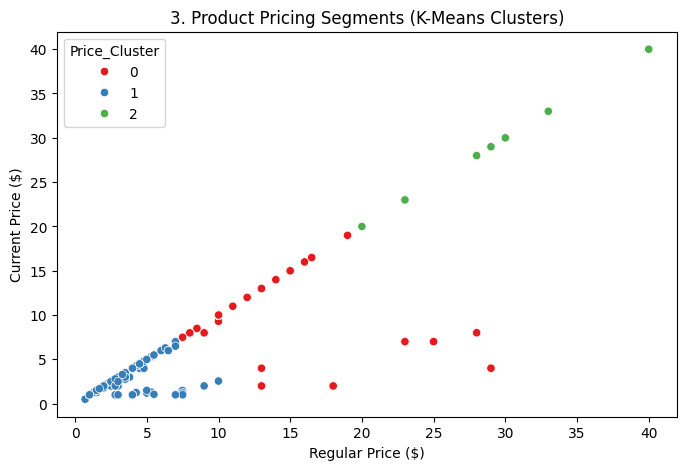


=== 🧼 K-MEANS CLUSTERING COMPLETE ===
Products have been grouped into 3 distinct price tiers and plotted above!


In [50]:
from sklearn.cluster import KMeans

# 1. Select the variables we want to cluster on
X_cluster = df[['Regular_Price', 'Current_Price']]

# 2. Tell K-Means to find exactly 3 groups
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Price_Cluster'] = kmeans.fit_predict(X_cluster)

# 3. Plot the clusters using Seaborn to see the groupings
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Regular_Price', y='Current_Price', hue='Price_Cluster', palette='Set1')
plt.title('3. Product Pricing Segments (K-Means Clusters)')
plt.xlabel('Regular Price ($)')
plt.ylabel('Current Price ($)')
plt.show()

print("\n=== 🧼 K-MEANS CLUSTERING COMPLETE ===")
print("Products have been grouped into 3 distinct price tiers and plotted above!")

In [51]:
df.to_csv('processed_grocery_prices.DataFrame', index=False)